# ROC Curve and Detection Performance Utilities

> **Note:** This notebook requires `scikit-learn`. To install, run:<br>
> `pip install scikit-learn`

---

## Theory

### What is an ROC Curve?

- The **Receiver Operating Characteristic (ROC) curve** plots the True Positive Rate (TPR, or sensitivity) versus the False Positive Rate (FPR, or 1-specificity) as you vary the decision threshold of your detector/classifier.
- **TPR (True Positive Rate):** Fraction of actual positives correctly detected. Also called sensitivity or recall.
- **FPR (False Positive Rate):** Fraction of actual negatives incorrectly detected as positive.
- The ROC curve shows the trade-off between detecting targets and avoiding false alarms.

### Area Under the Curve (AUC)

- **AUC (Area Under the Curve):** A single number (0–1) summarizing overall performance. 1.0 = perfect detection, 0.5 = random guessing.

### Why is it useful in DSP and Sonar?

- ROC curves are used to compare, tune, and select detection/classification algorithms (e.g., matched filters, ML classifiers, event detectors).
- They show how a detector performs over all possible thresholds (not just one operating point).
- In sonar, ROC analysis is crucial for detection algorithms in real noise, varying conditions, and class imbalance.

---


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


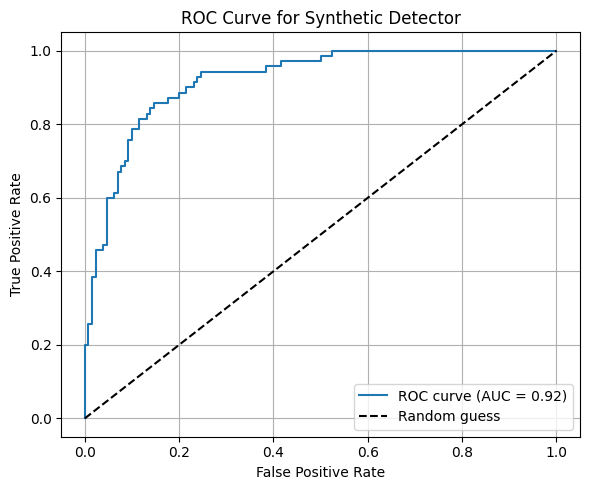

In [3]:
import numpy as np
import matplotlib.pyplot as plt
%pip install scikit-learn
from sklearn.metrics import roc_curve, auc

def plot_roc_curve(labels, scores, title='ROC Curve'):
    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# --- DEMO: Synthetic detector output ---
np.random.seed(42)
n = 200
labels = np.zeros(n)
labels[:70] = 1  # 70 targets, 130 non-targets
scores = np.random.normal(2, 1, 70).tolist() + np.random.normal(0, 1, 130).tolist()
scores = np.array(scores)

plot_roc_curve(labels, scores, title='ROC Curve for Synthetic Detector')


In [4]:
# The error is caused by a typo in cell 1: `%pip install scikit-learn` has an extra backtick at the end.
# To fix it, remove the trailing backtick so it reads:
# %pip install scikit-learn

# If you already have scikit-learn installed, you can ignore the pip install line.
# The rest of the code should work as expected.

---
## Usage Notes & Quick Reference

- This ROC code REQUIRES `scikit-learn` (install with `pip install scikit-learn` or `conda install scikit-learn`).
- Use with any detector, classifier, or matched filter output.
- **AUC > 0.8** = strong detector; **AUC ~0.5** = random.
- Use ROC for tuning and comparing algorithms in research, industry, and interviews.
- For rare-event (highly imbalanced) cases, also consider Precision-Recall curves.

---

**Standard for detection/classification benchmarking in science and engineering.**
